# Pairwise answer evaluation

**Recipe 23** · Level 2 (Easy) · Decision type: `Choice`

Compare two candidate answers against one explicit rubric criterion while retaining tie and insufficient-evidence outcomes for evaluation against human labels.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)

## What you will build

A judge that compares two candidate answers to the same question against one explicit rubric criterion, and decides `a`, `b`, `tie`, or `insufficient_evidence`. Jev is asked a purely positional `Choice` -- does the first candidate shown satisfy the criterion better, does the second, do the two come out equal, or does the criterion have nothing to go on in either one -- twice per comparison, with the two candidates' order swapped between the two requests. Python then accepts a verdict only when both orders agree, once relabelled back to the original candidates, and the lower of their two confidences clears a threshold chosen on `validation`; anything else goes to an explicit `review` outcome. By the end you will have looked at a comparison the two orders agree on and one they do not, seen the rule, and run an evaluation against human labels: raw accuracy and Cohen's kappa (on the rule's accepted verdicts and on every single-request verdict, so the two can be compared), the order-consistency rate, and the coverage, accuracy, and risk the frozen rule produces on held-out comparisons.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 82 stored answers in `fixtures/responses.json` (two requests for each of the 41 comparisons); setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definitions and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    cohens_kappa,
    confusion_matrix,
    evaluate_outcomes,
    evaluate_selective,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is every example with a gold label: validation and test, not demo.
scored = [e for e in examples if e.split != "demo"]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: a number from the validation split is a selection step, not a
# result. This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every comparison needs two requests: the two candidates in one order, then the same two with
# the order swapped. This cache makes sure neither request is ever made twice for the same
# comparison, however many times its answer is shown or scored later in this notebook, so the
# counter below is this notebook's real, dry-run request count -- the number the README's live
# budget note has to match.
_answered = {}
request_count = 0


def decide(example, swap):
    global request_count
    key = (example.id, swap)
    if key not in _answered:
        request_count += 1
        _answered[key] = backend.decide(helpers.build_state(example.fields, swap), questions)[
            "verdict"
        ]
    return _answered[key]


def both_orders(example):
    """(label_first, confidence_first, label_second, confidence_second): both requests'
    answers, already relabelled back to the comparison's own a/b/tie/insufficient_evidence."""
    label1, conf1 = helpers.read_verdict_answer(decide(example, False), example.fields, False)
    label2, conf2 = helpers.read_verdict_answer(decide(example, True), example.fields, True)
    return label1, conf1, label2, conf2


run_header(
    23,
    "Pairwise answer evaluation",
    backend=backend,
    n_examples=len(scored),
)

Recipe 23: Pairwise answer evaluation
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 39 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example's `fields` carries the question, the one rubric criterion for this comparison, the two candidate answers (`candidate_a`, `candidate_b`), and `a_shown_first`, a boolean Python uses to decide which candidate goes in which position. None of that bookkeeping reaches Jev: `build_state` passes on only the question, the criterion, and the two candidates in position order, as `first_answer` and `second_answer`. Calling it with `swap=True` builds the second request's state, with the same two candidates in the other order. Jev is never told which candidate is "a" and which is "b", so it cannot carry that identity across the two requests -- only Python, relabelling each answer afterwards, does that.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01"]
print("Python has:")
print(json.dumps({k: v for k, v in example.fields.items() if k != "a_shown_first"}, indent=2))
print(f"...and a_shown_first = {example.fields['a_shown_first']!r}, which never reaches Jev.")
print()
print("Jev sees, first request:")
print(json.dumps(helpers.build_state(example.fields, swap=False), indent=2))
print()
print("Jev sees, second request (order swapped):")
print(json.dumps(helpers.build_state(example.fields, swap=True), indent=2))

Python has:
{
  "question": "What's the return window for items bought during the holiday sale?",
  "criterion": "Which candidate answer more directly and specifically answers the exact question that was asked, rather than a related but different one?",
  "candidate_a": "Items bought during the holiday sale can be returned until January 31st, a longer window than our usual 30 days.",
  "candidate_b": "Return policies can sometimes be extended around the holidays, but it varies by retailer."
}
...and a_shown_first = False, which never reaches Jev.

Jev sees, first request:
{
  "question": "What's the return window for items bought during the holiday sale?",
  "criterion": "Which candidate answer more directly and specifically answers the exact question that was asked, rather than a related but different one?",
  "first_answer": "Return policies can sometimes be extended around the holidays, but it varies by retailer.",
  "second_answer": "Items bought during the holiday sale can be retu

## The questions

There is one question, and every state is a different comparison, but the question Jev is asked never mentions "a" or "b": it asks, given the stated criterion, whether the *first* candidate answer shown satisfies it better, the *second* does, the two come out equal, or the criterion has nothing to go on in either one. That instruction is literally true of every state this recipe builds, because `first_answer` and `second_answer` are always exactly the two fields `build_state` writes. The fixed option set is built by Python: `first` and `second` name a position, and `tie` and `insufficient_evidence` are the two outcomes the catalog's use case names explicitly -- `insufficient_evidence` is this recipe's fallback option (CONTRIBUTING.md section 3: "Include `none`, `other`, `no_match`, or `uncertain` outcomes when the use case calls for them"), and `tie` is retained rather than forced into a false win for either side.

`tie` and `insufficient_evidence` answer two different questions about the criterion, not "equally good" versus "equally bad": `tie` says the criterion *can* be judged against both candidates, and the judgment comes out the same either way (both clearly satisfy it, or both clearly fail it); `insufficient_evidence` says the criterion cannot be judged *at all*, because the question and the two candidates never contain the fact, number, name, or kind of claim the criterion is about -- for example, asking which answer is more factually *precise* about "the specific number, date, or name the question asks for" when the question never asked for one in the first place. Confusing the two was an earlier draft's mistake (an `insufficient_evidence` row whose candidates were just equally vague, which `tie`'s own wording already covers): every `insufficient_evidence` comparison below pairs a criterion with a question that has nothing for that criterion to grab onto, in either candidate, so there is nothing to compare rather than a tied failure to compare well.

In [3]:
verdict_question = questions["verdict"]
print(verdict_question.instructions)
for name, description in verdict_question.criteria.items():
    print(f"  {name:20s} {description}")

A question, one rubric criterion, and two candidate answers to the question, shown as 'first_answer' and 'second_answer'. Judging only by the stated criterion (ignore anything else that might make one answer seem better), does the first candidate answer satisfy it better, does the second, do the two come out equal, or does the criterion have nothing to go on in either one?
  first                The first candidate answer, as shown above, satisfies the stated criterion better than the second.
  second               The second candidate answer, as shown above, satisfies the stated criterion better than the first.
  tie                  Both candidate answers can be judged against the criterion, and they come out equal: either both clearly satisfy it, or both clearly fail it, to the same degree.
  insufficient_evidence The criterion cannot be judged at all from what is here: the question and the two candidate answers do not contain the fact, number, name, or kind of claim the criterion i

A `Choice` answer's `confidence` is the top probability rescaled by the number of options -- here four, `first`, `second`, `tie`, `insufficient_evidence` -- `(p_max - 1/4) / (1 - 1/4)`, or `(p_max - 0.25) / 0.75`: 0 when the top option has no more than an even quarter share, 1 when one option holds all the probability. It says how far the top option pulled ahead of an even split among the four, not how strongly Jev feels about any particular candidate.

Each comparison makes **two** requests, not one: the candidates in whichever order `a_shown_first` picks, then the same two candidates with that order swapped. These are two separate, independent requests, not a dependent follow-up in TypeSafe's sense (S02): Python decides the swap in advance, without needing the first request's answer to build the second one. But the two requests still describe two *different* states -- the candidates change position -- and S02 says independent *questions about the same state* belong in one request; these are not that, so they still need a request each. `docs/fixtures.md` calls for exactly this: every example below lists two replay keys, in the order the two requests are made.

The options are ordered `first`, `second`, `tie`, `insufficient_evidence`, so a model that leans toward whichever option comes first in its list -- a documented `Choice` failure mode on some TypeSafe models, though not one either of this recipe's sources (S02, S03) documents -- would, here, lean toward whichever *candidate* happens to be shown first. That is exactly the failure this recipe's design catches: a lean toward the first position makes the two requests relabel to different candidates (the one that was first each time), so `judge_pair` sends the pair to `review` for disagreeing instead of reporting the biased pick as a result. Several comparisons in this recipe's fixtures are authored, by hand, with exactly that disagreement, to exercise the check; that is a property of the fixtures, not a measurement of how Jev actually responds to candidate order, since the stored answers come from no model.

Which candidate is shown first in each comparison's *first* request (`a_shown_first`) is decided once, by `helpers.assign_first_shown`, which hashes each comparison's id together with a fixed seed (`helpers.ORDER_SEED`) -- never the id's position in the fixture list, and never the **gold label** (the correct answer a person wrote down for a comparison, stored in `fixtures/labels.jsonl` and used only to score an answer after the fact, never shown to Jev; see the [glossary](../../docs/glossary.md#gold-label)) or the candidate text. That rules out one specific risk: `ROWS` in `build_fixtures.py` is grouped by gold label, so an id's *position* in the list is a near-perfect stand-in for its gold label, and a sequential random-number draw (one call per id, in list order) would have inherited that correlation even without ever reading the label itself. Hashing each id on its own breaks that link. It does not, by itself, prove the realised assignment below is balanced across gold labels -- that is a further fact about this one draw, not a guarantee the function makes, and the table reports it rather than asserting it.

In [4]:
from collections import Counter

order_table = Counter((labels[e.id], e.fields["a_shown_first"]) for e in scored)
print(f"{'gold label':24s} {'a first':>10s} {'b first':>10s} {'share a first':>14s}")
for label in helpers.LABELS:
    a_first = order_table[(label, True)]
    b_first = order_table[(label, False)]
    total = a_first + b_first
    share = f"{a_first / total:.3f}" if total else "n/a"
    print(f"{label:24s} {a_first:>10d} {b_first:>10d} {share:>14s}")

gold label                  a first    b first  share a first
a                                 6          5          0.545
b                                 2          8          0.200
tie                               4          5          0.444
insufficient_evidence             2          7          0.222


This is one draw, not a guarantee: `a` and `tie` land close to an even split, but `b` and `insufficient_evidence` do not -- combining those two rows, candidate `a` is shown first in only 4 of 19 such comparisons (the `share a first` column: 0.200 and 0.222), so candidate `b` is the one shown first the other 15 times, under those two gold labels. The hashing above only rules out the assignment *using* the gold label to decide; it says nothing about whether this particular draw happens to balance evenly across labels, and here it does not, for two of the four. A different `ORDER_SEED` would give a different draw and a different table; this recipe keeps the id-derived hash and reports whatever table it produces rather than searching for a more balanced one.

## One answer up close

Before any aggregate, look at two comparisons: one where the two orders agree, and one where they do not. Each request's answer holds the chosen position, a probability for every option, and the `confidence` explained above; `helpers.read_verdict_answer` relabels the chosen position back to `a`, `b`, `tie`, or `insufficient_evidence`, using which candidate was actually first in that request.

In [5]:
consistent_example = demo["d01"]
print(f"Question: {consistent_example.fields['question']}")
print(f"Criterion: {consistent_example.fields['criterion']}")
print(f"Candidate a: {consistent_example.fields['candidate_a']}")
print(f"Candidate b: {consistent_example.fields['candidate_b']}")
print()
a1 = decide(consistent_example, swap=False)
a2 = decide(consistent_example, swap=True)
print("First request:")
show_answer(a1)
print("Second request (order swapped):")
show_answer(a2)
label1, conf1, label2, conf2 = both_orders(consistent_example)
print(
    f"Relabelled: first request says {label1!r} (confidence {conf1:.2f}); second says {label2!r} (confidence {conf2:.2f})"
)

Question: What's the return window for items bought during the holiday sale?
Criterion: Which candidate answer more directly and specifically answers the exact question that was asked, rather than a related but different one?
Candidate a: Items bought during the holiday sale can be returned until January 31st, a longer window than our usual 30 days.
Candidate b: Return policies can sometimes be extended around the holidays, but it varies by retailer.

First request:
Choice: second (confidence 0.90)
  second                 0.93  ##################
  first                  0.02  
  tie                    0.02  
  insufficient_evidence  0.02  
Provenance: synthetic
Second request (order swapped):
Choice: first (confidence 0.88)
  first                  0.91  ##################
  second                 0.03  #
  tie                    0.03  #
  insufficient_evidence  0.03  #
Provenance: synthetic
Relabelled: first request says 'a' (confidence 0.90); second says 'a' (confidence 0.88)


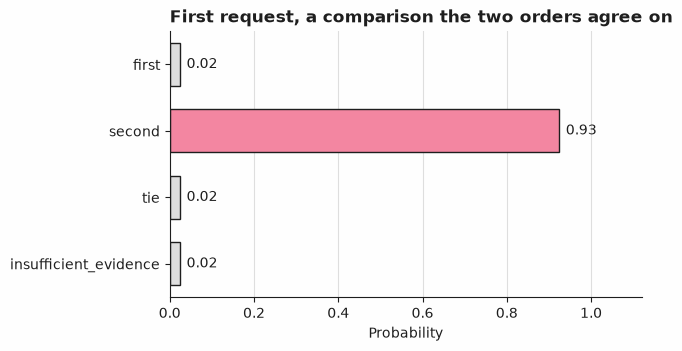

In [6]:
plot_answer_probabilities(a1, title="First request, a comparison the two orders agree on")

Candidate `a` names the actual return deadline; candidate `b` only hedges about whether retailers extend their policies. Both requests put the most probability on whichever position `a` happens to occupy, so this comparison's two orders agree once relabelled -- the ordinary case this recipe's fixtures mostly contain.

In [7]:
inconsistent_example = demo["d02"]
print(f"Question: {inconsistent_example.fields['question']}")
print(f"Criterion: {inconsistent_example.fields['criterion']}")
print(f"Candidate a: {inconsistent_example.fields['candidate_a']}")
print(f"Candidate b: {inconsistent_example.fields['candidate_b']}")
print()
b1 = decide(inconsistent_example, swap=False)
b2 = decide(inconsistent_example, swap=True)
print("First request:")
show_answer(b1)
print("Second request (order swapped):")
show_answer(b2)
ilabel1, iconf1, ilabel2, iconf2 = both_orders(inconsistent_example)
print(
    f"Relabelled: first request says {ilabel1!r} (confidence {iconf1:.2f}); second says {ilabel2!r} (confidence {iconf2:.2f})"
)

Question: Which of these two trail maps shows the shorter route to the waterfall?
Criterion: Which candidate answer stays on the one topic the question raises, rather than drifting into unrelated advice?
Candidate a: The waterfall trail connects to several other paths in the park, so hikers have options.
Candidate b: This map's route to the waterfall is about a mile, roughly half the distance of the other one.

First request:
Choice: second (confidence 0.65)
  second                 0.74  ###############
  first                  0.09  ##
  tie                    0.09  ##
  insufficient_evidence  0.09  ##
Provenance: synthetic
Second request (order swapped):
Choice: second (confidence 0.60)
  second                 0.70  ##############
  first                  0.10  ##
  tie                    0.10  ##
  insufficient_evidence  0.10  ##
Provenance: synthetic
Relabelled: first request says 'b' (confidence 0.65); second says 'a' (confidence 0.60)


Here the two requests disagree once relabelled: one names `a`, the other names `b`. "Python's part" below shows what the rule does with exactly this shape of disagreement.

## Python's part

Jev supplies two positional judgments; the rule that turns them into one verdict is code. `helpers.judge_pair` checks, in order: first, whether the two requests agree with each other once relabelled -- if not, the comparison goes to `review` with the reason `"orders disagree"`, whatever either confidence is, because a disagreement between a comparison's own two orders is exactly the failure this recipe exists to catch, and no confidence number excuses it. Among comparisons where the two orders agree, `insufficient_evidence` is accepted immediately, with no confidence check at all: choosing it promotes neither candidate and triggers no side effect, so there is nothing left for a confidence gate to protect (CONTRIBUTING.md section 4, "a low-confidence fallback option ... may be delivered as a final result instead of going to review, but only when choosing it triggers no side effect"). Every other agreed label (`a`, `b`, `tie`) still needs the lower of the two requests' confidences to clear a threshold, below which the comparison goes to `review` with the reason `"confidence below the threshold"`. That exemption is not free, though: "Evaluation" below has a comparison where both requests agree, confidently, on `insufficient_evidence` and gold disagrees, and it counts fully against `test`'s risk.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook. Only comparisons where the two orders already agree on `a`, `b`, or `tie` can set it: an `insufficient_evidence` comparison is accepted without reference to any threshold, and a disagreeing comparison has no single confidence to calibrate. `select_confidence_threshold` picks the lowest such confidence at which every one of those agreeing `validation` comparisons is correct, which keeps as much of `validation` automatic as the fixtures allow without accepting a wrong verdict *on validation*. Applying that frozen threshold to the two comparisons shown above demonstrates both outcomes the rule can produce.

In [8]:
val_examples = select_split(examples, "validation")
val_pairs = {e.id: both_orders(e) for e in val_examples}
eligible = [
    (label1 == labels[e.id], min(conf1, conf2))
    for e in val_examples
    for label1, conf1, label2, conf2 in [val_pairs[e.id]]
    if label1 == label2 and label1 != helpers.INSUFFICIENT
]
threshold = select_confidence_threshold(
    [ok for ok, _ in eligible], [c for _, c in eligible], target_accuracy=1.0
)
print(
    f"validation comparisons where both orders agree on a, b, or tie: "
    f"{len(eligible)} of {len(val_examples)}{selection}{check}"
)
print(f"chosen confidence gate, frozen from here on: {threshold:.4f}{selection}{check}")

for name, example in (("consistent", consistent_example), ("inconsistent", inconsistent_example)):
    label1, conf1, label2, conf2 = both_orders(example)
    verdict = helpers.judge_pair(example.id, label1, conf1, label2, conf2, threshold)
    print(
        f"{example.id} ({name}): first={label1!r} ({conf1:.2f})  second={label2!r} ({conf2:.2f})"
        f" -> {verdict.outcome} ({verdict.reason})"
    )

validation comparisons where both orders agree on a, b, or tie: 12 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
chosen confidence gate, frozen from here on: 0.5300 (a selection step, not a reported result) (a pipeline check, not a Jev result)
d01 (consistent): first='a' (0.90)  second='a' (0.88) -> accepted (orders agree and confidence clears the threshold)
d02 (inconsistent): first='b' (0.65)  second='a' (0.60) -> review (orders disagree)


## Evaluation

The confidence gate was chosen and frozen above, on `validation`. This section reports what the frozen rule, `helpers.judge_pair`, actually does when applied to every comparison in `validation` and in `test`, starting with what it accepted versus sent to `review`, and why.

In [9]:
test_examples = select_split(examples, "test")
test_pairs = {e.id: both_orders(e) for e in test_examples}

val_verdicts = {e.id: helpers.judge_pair(e.id, *val_pairs[e.id], threshold) for e in val_examples}
test_verdicts = {
    e.id: helpers.judge_pair(e.id, *test_pairs[e.id], threshold) for e in test_examples
}


def reasons_breakdown(verdicts):
    reasons = {}
    for v in verdicts.values():
        if v.outcome == helpers.REVIEW:
            reasons[v.reason] = reasons.get(v.reason, 0) + 1
    return reasons


for name, split_examples, verdicts, suffix in (
    ("validation", val_examples, val_verdicts, f"{selection}{check}"),
    ("test", test_examples, test_verdicts, check),
):
    n_accepted = sum(1 for v in verdicts.values() if v.outcome == helpers.ACCEPTED)
    print(f"{name}, {len(split_examples)} comparisons{suffix}")
    print(f"  accepted: {n_accepted} of {len(split_examples)}{suffix}")
    for reason, count in sorted(reasons_breakdown(verdicts).items()):
        print(f"  sent to review because {reason!r}: {count}{suffix}")

validation, 19 comparisons (a selection step, not a reported result) (a pipeline check, not a Jev result)
  accepted: 14 of 19 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  sent to review because 'confidence below the threshold': 1 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  sent to review because 'orders disagree': 4 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test, 20 comparisons (a pipeline check, not a Jev result)
  accepted: 14 of 20 (a pipeline check, not a Jev result)
  sent to review because 'confidence below the threshold': 1 (a pipeline check, not a Jev result)
  sent to review because 'orders disagree': 5 (a pipeline check, not a Jev result)


`coverage` is the fraction of comparisons the rule accepted rather than sending to review; among those, `accuracy` is the fraction whose accepted label matches the human gold label; `risk` is its complement, `1 - accuracy` -- the fraction of accepted comparisons that are nonetheless wrong. `judge_pair`'s review branch is more than a single confidence gate (a disagreeing pair is sent to review however confident either request is), so these three numbers come from the rule's own accept/review decisions, via `jev_cookbook.evaluation.evaluate_outcomes(accepted, correct)`, rather than from reapplying one confidence threshold to every comparison.

In [10]:
def outcomes_for(split_examples, verdicts):
    accepted = [verdicts[e.id].outcome == helpers.ACCEPTED for e in split_examples]
    correct = [
        verdicts[e.id].label == labels[e.id]
        if verdicts[e.id].outcome == helpers.ACCEPTED
        else False
        for e in split_examples
    ]
    return evaluate_outcomes(accepted, correct)


val_outcomes = outcomes_for(val_examples, val_verdicts)
test_outcomes = outcomes_for(test_examples, test_verdicts)
print(
    f"validation: coverage {val_outcomes.coverage:.4f}  accuracy {val_outcomes.accuracy:.4f}  "
    f"risk {val_outcomes.risk:.4f}{selection}{check}"
)
print(
    f"test:       coverage {test_outcomes.coverage:.4f}  accuracy {test_outcomes.accuracy:.4f}  "
    f"risk {test_outcomes.risk:.4f}{check}"
)

wrong_but_accepted = [
    e.id
    for e in test_examples
    if test_verdicts[e.id].outcome == helpers.ACCEPTED and test_verdicts[e.id].label != labels[e.id]
]
print(f"accepted but wrong on test: {wrong_but_accepted}{check}")

validation: coverage 0.7368  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test:       coverage 0.7000  accuracy 0.8571  risk 0.1429 (a pipeline check, not a Jev result)
accepted but wrong on test: ['t04', 't20'] (a pipeline check, not a Jev result)


`validation`'s risk is zero by construction: the threshold was chosen to be perfectly accurate on exactly these comparisons. `test`'s is not, for two different reasons, one per comparison named above. The first is a comparison where both requests agree with each other, confidently, on a candidate that is not the one the human label prefers -- the swap-consistency check cannot catch this, because the two requests agree with *each other*, just not with the person who wrote the label; a confidence gate that is perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any comparison this recipe has not seen. The second is a comparison both requests confidently call `insufficient_evidence` while the criterion is, in fact, plainly judgeable -- this is the cost "Python's part" above said the `insufficient_evidence` exemption was not free; nothing catches it, by the rule's own design, because an agreed `insufficient_evidence` never reaches the confidence gate at all.

Coverage, accuracy, and risk above tally every accepted verdict together; this use case asks for the uncertain outcome to be reported separately, so the cell below breaks the accepted verdicts down by label on each split, `insufficient_evidence` included.

In [11]:
def accepted_by_label(split_examples, verdicts):
    tally = {}
    for e in split_examples:
        v = verdicts[e.id]
        if v.outcome == helpers.ACCEPTED:
            tally[v.label] = tally.get(v.label, 0) + 1
    return tally


for name, split_examples, verdicts, suffix in (
    ("validation", val_examples, val_verdicts, f"{selection}{check}"),
    ("test", test_examples, test_verdicts, check),
):
    tally = accepted_by_label(split_examples, verdicts)
    print(f"{name} accepted verdicts by label{suffix}")
    for label in helpers.LABELS:
        print(f"  {label:24s} {tally.get(label, 0)}{suffix}")

validation accepted verdicts by label (a selection step, not a reported result) (a pipeline check, not a Jev result)
  a                        3 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  b                        4 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  tie                      4 (a selection step, not a reported result) (a pipeline check, not a Jev result)
  insufficient_evidence    3 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test accepted verdicts by label (a pipeline check, not a Jev result)
  a                        3 (a pipeline check, not a Jev result)
  b                        3 (a pipeline check, not a Jev result)
  tie                      3 (a pipeline check, not a Jev result)
  insufficient_evidence    5 (a pipeline check, not a Jev result)


The **order-consistency rate** is the share of comparisons where the two requests, once relabelled, name the same answer -- both `a`, both `b`, both `tie`, or both `insufficient_evidence` -- independent of whether that shared answer is actually right. It is the fraction of comparisons the swap check lets through to the confidence gate at all.

In [12]:
def consistency_rate(split_examples, pairs):
    agree = sum(1 for e in split_examples if pairs[e.id][0] == pairs[e.id][2])
    return agree, len(split_examples)


val_agree, val_n = consistency_rate(val_examples, val_pairs)
test_agree, test_n = consistency_rate(test_examples, test_pairs)
print(
    f"validation order-consistency rate: {val_agree} of {val_n} = {val_agree / val_n:.4f}{selection}{check}"
)
print(
    f"test order-consistency rate:       {test_agree} of {test_n} = {test_agree / test_n:.4f}{check}"
)

validation order-consistency rate: 15 of 19 = 0.7895 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test order-consistency rate:       15 of 20 = 0.7500 (a pipeline check, not a Jev result)


**Cohen's kappa** measures agreement with the human labels beyond what matching by chance alone would already give: 0 at chance-level agreement, 1 at perfect agreement, and negative below chance; `jev_cookbook.evaluation.cohens_kappa` computes it from the gold labels and the predicted ones. Two different populations are worth comparing here. *All first-order verdicts* is what a single, unswapped request would have said about every comparison -- its relabelled answer, whether or not that answer agrees with its own swapped-order twin. *Accepted verdicts* is what `judge_pair` actually reports, once the comparisons it sends to `review` (disagreeing or under-confident) are removed. The gap between the two is the swap-and-gate pipeline's whole case for existing.

In [13]:
def first_order_stats(split_examples, pairs):
    gold = [labels[e.id] for e in split_examples]
    predicted = [pairs[e.id][0] for e in split_examples]
    return accuracy(gold, predicted), cohens_kappa(gold, predicted)


def accepted_stats(split_examples, verdicts):
    scored_pairs = [
        (labels[e.id], verdicts[e.id].label)
        for e in split_examples
        if verdicts[e.id].outcome == helpers.ACCEPTED
    ]
    gold = [g for g, _ in scored_pairs]
    predicted = [p for _, p in scored_pairs]
    return accuracy(gold, predicted), cohens_kappa(gold, predicted), len(scored_pairs)


val_fo_acc, val_fo_kappa = first_order_stats(val_examples, val_pairs)
test_fo_acc, test_fo_kappa = first_order_stats(test_examples, test_pairs)
val_ac_acc, val_ac_kappa, val_ac_n = accepted_stats(val_examples, val_verdicts)
test_ac_acc, test_ac_kappa, test_ac_n = accepted_stats(test_examples, test_verdicts)

print(
    f"all first-order verdicts, validation: accuracy {val_fo_acc:.4f}  kappa {val_fo_kappa:.4f}{selection}{check}"
)
print(
    f"all first-order verdicts, test:       accuracy {test_fo_acc:.4f}  kappa {test_fo_kappa:.4f}{check}"
)
print(
    f"accepted verdicts, validation ({val_ac_n} of {len(val_examples)}): "
    f"accuracy {val_ac_acc:.4f}  kappa {val_ac_kappa:.4f}{selection}{check}"
)
print(
    f"accepted verdicts, test ({test_ac_n} of {len(test_examples)}):       "
    f"accuracy {test_ac_acc:.4f}  kappa {test_ac_kappa:.4f}{check}"
)

all first-order verdicts, validation: accuracy 0.8421  kappa 0.7889 (a selection step, not a reported result) (a pipeline check, not a Jev result)
all first-order verdicts, test:       accuracy 0.7500  kappa 0.6656 (a pipeline check, not a Jev result)
accepted verdicts, validation (14 of 19): accuracy 1.0000  kappa 1.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
accepted verdicts, test (14 of 20):       accuracy 0.8571  kappa 0.8082 (a pipeline check, not a Jev result)


On both splits, accepted verdicts agree with the human labels more than all first-order verdicts do, on both accuracy and kappa. That gap is this fixture set's own construction, not a discovery about Jev: the inconsistent pairs were written by hand specifically so the swap check would catch them, and every stored answer is keyed to its gold label on purpose. What this cell checks is that the pipeline behaves the way it is meant to -- rejecting the comparisons it was built to reject improves agreement on the ones that remain -- not that a single request is noisier than a checked one in general. `validation`'s accepted-verdicts kappa is 1.0 by the same construction that gives it zero risk above.

`judge_pair`'s review branch is not only a confidence gate: a disagreeing comparison goes to `review` whatever either confidence is. `jev_cookbook.evaluation.evaluate_selective` only ever reapplies one confidence threshold to a fixed correctness array, so feeding it a confidence signal for every comparison (the lower of the two requests' confidences) and the first request's own correctness answers a different question than `judge_pair` asks. The cell below checks, rather than assumes, whether the two actually disagree on this fixture set.

In [14]:
def gate_only_view(split_examples, pairs):
    correct_first_order = [pairs[e.id][0] == labels[e.id] for e in split_examples]
    gate_confidence = [min(pairs[e.id][1], pairs[e.id][3]) for e in split_examples]
    return evaluate_selective(correct_first_order, gate_confidence, threshold)


val_selective = gate_only_view(val_examples, val_pairs)
test_selective = gate_only_view(test_examples, test_pairs)


def same_numbers(selective, outcomes):
    return (selective.n_answered, selective.coverage, selective.accuracy, selective.risk) == (
        outcomes.n_answered,
        outcomes.coverage,
        outcomes.accuracy,
        outcomes.risk,
    )


if same_numbers(val_selective, val_outcomes) and same_numbers(test_selective, test_outcomes):
    print(
        f"evaluate_selective's gate-only view and evaluate_outcomes agree on every number here{check}"
    )
else:
    print(
        f"validation, evaluate_selective (gate only): coverage {val_selective.coverage:.4f}  "
        f"accuracy {val_selective.accuracy:.4f}  risk {val_selective.risk:.4f}{selection}{check}"
    )
    print(
        f"validation, evaluate_outcomes (the rule):   coverage {val_outcomes.coverage:.4f}  "
        f"accuracy {val_outcomes.accuracy:.4f}  risk {val_outcomes.risk:.4f}{selection}{check}"
    )
    print(
        f"test,       evaluate_selective (gate only): coverage {test_selective.coverage:.4f}  "
        f"accuracy {test_selective.accuracy:.4f}  risk {test_selective.risk:.4f}{check}"
    )
    print(
        f"test,       evaluate_outcomes (the rule):   coverage {test_outcomes.coverage:.4f}  "
        f"accuracy {test_outcomes.accuracy:.4f}  risk {test_outcomes.risk:.4f}{check}"
    )


def gate_would_accept(e, pairs):
    return min(pairs[e.id][1], pairs[e.id][3]) >= threshold


wrongly_accepted_by_gate = [
    e.id
    for e in test_examples
    if gate_would_accept(e, test_pairs) and test_verdicts[e.id].outcome != helpers.ACCEPTED
]
wrongly_rejected_by_gate = [
    e.id
    for e in test_examples
    if not gate_would_accept(e, test_pairs) and test_verdicts[e.id].outcome == helpers.ACCEPTED
]
print(
    f"test comparisons the gate-only view accepts but judge_pair sends to review: {wrongly_accepted_by_gate}{check}"
)
print(
    f"test comparisons the gate-only view rejects but judge_pair accepts: {wrongly_rejected_by_gate}{check}"
)

validation, evaluate_selective (gate only): coverage 0.8947  accuracy 0.8824  risk 0.1176 (a selection step, not a reported result) (a pipeline check, not a Jev result)
validation, evaluate_outcomes (the rule):   coverage 0.7368  accuracy 1.0000  risk 0.0000 (a selection step, not a reported result) (a pipeline check, not a Jev result)
test,       evaluate_selective (gate only): coverage 0.9000  accuracy 0.7222  risk 0.2778 (a pipeline check, not a Jev result)
test,       evaluate_outcomes (the rule):   coverage 0.7000  accuracy 0.8571  risk 0.1429 (a pipeline check, not a Jev result)
test comparisons the gate-only view accepts but judge_pair sends to review: ['t05', 't09', 't10', 't14', 't19'] (a pipeline check, not a Jev result)
test comparisons the gate-only view rejects but judge_pair accepts: ['t15'] (a pipeline check, not a Jev result)


The two views disagree for two different reasons, each named above. The first group are comparisons whose two requests disagree with each other but whose lower confidence still clears the gate: a view that only ever checks confidence wrongly accepts them, while `judge_pair` sends each to `review` for disagreeing. The second group is the opposite: a comparison whose two requests agree on `insufficient_evidence` at a confidence below the gate -- the gate-only view wrongly rejects it, while `judge_pair` accepts it immediately, because `insufficient_evidence` never goes through the confidence gate at all. This is exactly the shape `docs/evaluation.md` describes for a rule whose review branch is more than a confidence gate, and it is why coverage, accuracy, and risk above come from `evaluate_outcomes`, not `evaluate_selective`.

A trivial baseline shows whether the pipeline, applied to this fixture set, is doing any real work. "Always pick `a`" ignores both candidates entirely; "the longer answer wins" looks only at which candidate has more characters, never at the stated criterion. The accepted-verdicts accuracy reported above should clearly beat both on these fixtures -- since the stored answers are authored to agree with the gold label on most comparisons, this is a check that the rule's logic and this evaluation code are wired together correctly, not a measurement of how a context-free baseline would fare against Jev on real comparisons.

In [15]:
def baseline_always_a(split_examples):
    gold = [labels[e.id] for e in split_examples]
    predicted = [helpers.A] * len(split_examples)
    return accuracy(gold, predicted)


def baseline_longer_answer(split_examples):
    gold, predicted = [], []
    for e in split_examples:
        a_text, b_text = e.fields["candidate_a"], e.fields["candidate_b"]
        if len(a_text) == len(b_text):
            predicted.append(helpers.TIE)
        elif len(a_text) > len(b_text):
            predicted.append(helpers.A)
        else:
            predicted.append(helpers.B)
        gold.append(labels[e.id])
    return accuracy(gold, predicted)


print(f"test, always-a baseline accuracy: {baseline_always_a(test_examples):.4f}{check}")
print(
    f"test, longer-answer-wins baseline accuracy: {baseline_longer_answer(test_examples):.4f}{check}"
)
print(f"test, accepted-verdicts accuracy (from above): {test_ac_acc:.4f}{check}")

test, always-a baseline accuracy: 0.3000 (a pipeline check, not a Jev result)
test, longer-answer-wins baseline accuracy: 0.4000 (a pipeline check, not a Jev result)
test, accepted-verdicts accuracy (from above): 0.8571 (a pipeline check, not a Jev result)


The confusion matrix below covers every `test` comparison's first-order verdict against its gold label (full coverage, unlike the accepted-verdicts numbers above, which only cover comparisons the rule accepted).

In [ ]:
test_first_order = [test_pairs[e.id][0] for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]
matrix = confusion_matrix(test_gold, test_first_order, labels=list(helpers.LABELS))
print(f"gold (row) by first-order verdict (column), {len(helpers.LABELS)} labels{check}:")
header = "  ".join(f"{label:>19s}" for label in matrix.labels)
print(f"  predicted ->  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:19d}" for count in row)
    print(f"  gold {gold_label:<19s}  {counts}{check}")
plot_confusion_matrix(
    matrix, title=f"Test split, all first-order verdicts, {len(test_examples)} comparisons{check}"
)

## What was and was not measured

What this run can say about Jev depends on its mode, which the cell below states from `backend.mode`: a synthetic or scripted run is a pipeline check only, on the fixture sample it ran against; a recorded or live run states the model the API returned and when, for exactly the comparisons it covers. Nothing here says anything about Jev's quality, speed, or cost unless that cell reports a recorded or live run. `N` below counts only the comparisons that carry a gold label, so it excludes the two `demo` comparisons shown earlier.

In [17]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test comparisons")
print(f"Requests made in this run: {request_count}")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.
Requests made in this run: 82


## Next steps

- Change `target_accuracy=1.0` in the threshold cell to `0.9` and re-run "Python's part" and the Evaluation cells: the confidence gate drops from 0.5300 to 0.5200, because it can now tolerate the one wrong, consistent `validation` comparison that forced it up in the first place -- coverage and risk both move.
- Add a new comparison to `ROWS` in `build_fixtures.py` with the same criterion as an existing one but different candidates, run `python build_fixtures.py`, and see which outcome `judge_pair` gives it.
- Neighbouring recipes: [`03-response-clarity-scoring`](../03-response-clarity-scoring/) (a `Score` rubric over one answer rather than a comparison between two), [`10-answer-relevance-check`](../10-answer-relevance-check/) (a `Noul` three-path pattern judging one answer's relevance), and [`08-faq-selection`](../08-faq-selection/) (a `Choice` with its own explicit fallback option, `no_match`, accepted the same way `insufficient_evidence` is accepted here).